# Q2 · Simulation quickstart

What works today: chirp generation, pulse compression, presumming, multilook. What Q2 builds: the echo generator (D2.3) and SAR focusing (D2.5).

Run `pytest` after each piece you build: tests V-03 and V-05 switch on by themselves.

In [1]:
# Setup — run this first. Finds the repo on your computer; in Google Colab it asks
# which GitHub repo to load and clones it.
import sys, pathlib, subprocess

def _find_repo():
    for d in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (d / "params" / "variables.yaml").exists():
            return d
    return None

ROOT = _find_repo()
if ROOT is None and "google.colab" in sys.modules:
    repo = input("GitHub repo to load (owner/name): ").strip()
    subprocess.run(["git", "clone", "--depth", "1", f"https://github.com/{repo}.git", "/content/repo"], check=True)
    ROOT = pathlib.Path("/content/repo")
if ROOT is None:
    raise RuntimeError("Open this notebook from inside the repo folder, or in Google Colab.")
sys.path.insert(0, str(ROOT))
print("Repo found ✓")

Repo found ✓


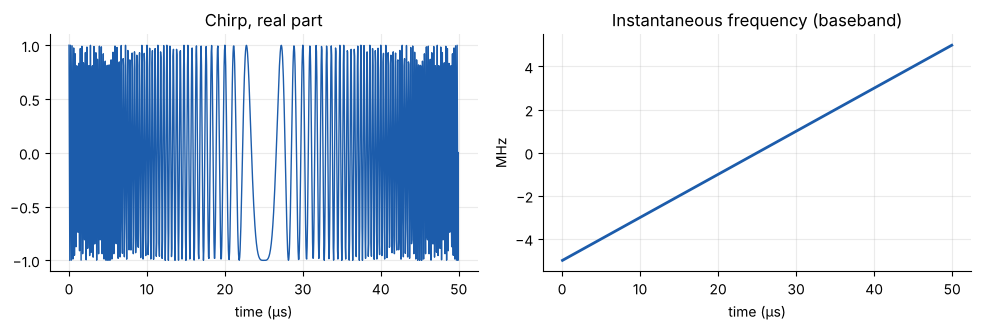

In [2]:
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (8, 4.2), "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
RAMP = ["#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]   # one blue, light → dark, for ordered values
import numpy as np
from hs3gpr.params import load
from hs3gpr.sim import waveform, receiver, onboard

p = load()
fs = p["sim_sample_rate"]
ref = waveform.chirp(p["chirp_length"], p["bandwidth"], fs)
t_us = np.arange(len(ref)) / fs * 1e6
inst_f = np.diff(np.unwrap(np.angle(ref))) * fs / (2 * np.pi) / 1e6
fig, (a, b) = plt.subplots(1, 2, figsize=(10, 3.4))
a.plot(t_us, ref.real, color=RAMP[2], lw=1)
a.set(title="Chirp, real part", xlabel="time (µs)")
b.plot(t_us[1:], inst_f, color=RAMP[2], lw=2)
b.set(title="Instantaneous frequency (baseband)", xlabel="time (µs)", ylabel="MHz")
plt.tight_layout(); plt.show()

## Pulse compression pulls a buried echo out of the noise

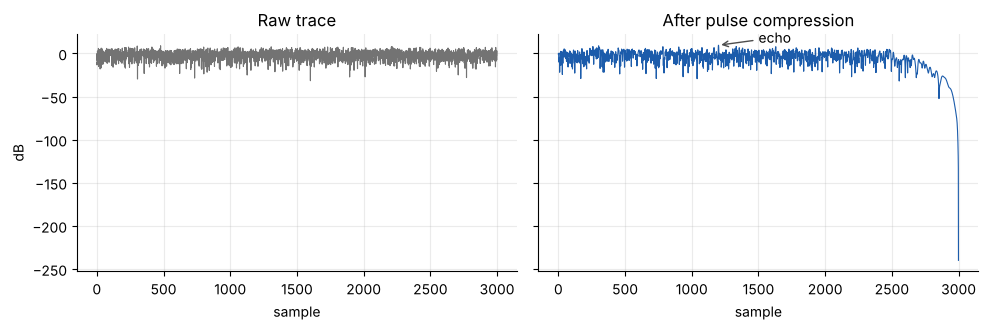

Expected compression gain: 28.2 dB


In [3]:
rng = np.random.default_rng(0)
n, start = 3000, 1200
trace = np.zeros(n, complex)
trace[start:start + len(ref)] = 0.08 * ref          # echo well below the noise
noisy = receiver.add_noise(trace[None, :], 1.0, rng)
compressed = waveform.pulse_compress(noisy, ref, p["range_window"])[0]
fig, (a, b) = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
db = lambda x: 20 * np.log10(np.abs(x) + 1e-12)
a.plot(db(noisy[0]), color="0.45", lw=0.8); a.set(title="Raw trace", xlabel="sample", ylabel="dB")
b.plot(db(compressed), color=RAMP[2], lw=0.8); b.set(title="After pulse compression", xlabel="sample")
b.annotate("echo", (start, db(compressed[start])), xytext=(start + 300, db(compressed[start]) + 3),
           arrowprops=dict(arrowstyle="->", color="0.3"))
plt.tight_layout(); plt.show()
gain = waveform.compression_gain(p["range_window"], p["chirp_length"], fs)
print(f"Expected compression gain: {10*np.log10(gain):.1f} dB")

## Presumming: N traces in, one trace out

In [4]:
N = int(p["presum_factor"])
raw = receiver.add_noise(np.full((N * 200, 64), 0.1 + 0j), 1.0, rng)
summed = onboard.presum(raw, N)
snr = lambda x: 10 * np.log10(np.abs(x.mean()) ** 2 / x.var())
print(f"SNR before: {snr(raw[:, 0]):.1f} dB · after presum ×{N}: {snr(summed[:, 0]):.1f} dB "
      f"(expected +{10*np.log10(N):.1f} dB) · data volume ÷{N}")

SNR before: -19.7 dB · after presum ×16: -7.4 dB (expected +12.0 dB) · data volume ÷16


## Next for Q2

1. `hs3gpr/sim/echo.py` → `simulate_traces` (D2.3). Start with point targets.
2. `hs3gpr/sim/ground.py` → `sar_focus` (D2.5). Back-projection first.
3. Run `pytest`. When V-03 passes, add layers and the void, then make V-05 pass.